Evaluating K values...

K=2 | Inertia=9260.61 | Silhouette=0.1085
K=3 | Inertia=8105.14 | Silhouette=0.1123
K=4 | Inertia=7267.26 | Silhouette=0.1244
K=5 | Inertia=6865.09 | Silhouette=0.1112
K=6 | Inertia=6571.02 | Silhouette=0.1106
K=7 | Inertia=6342.98 | Silhouette=0.1030
K=8 | Inertia=6189.33 | Silhouette=0.1060
K=9 | Inertia=6095.05 | Silhouette=0.0865
K=10 | Inertia=5985.65 | Silhouette=0.0889


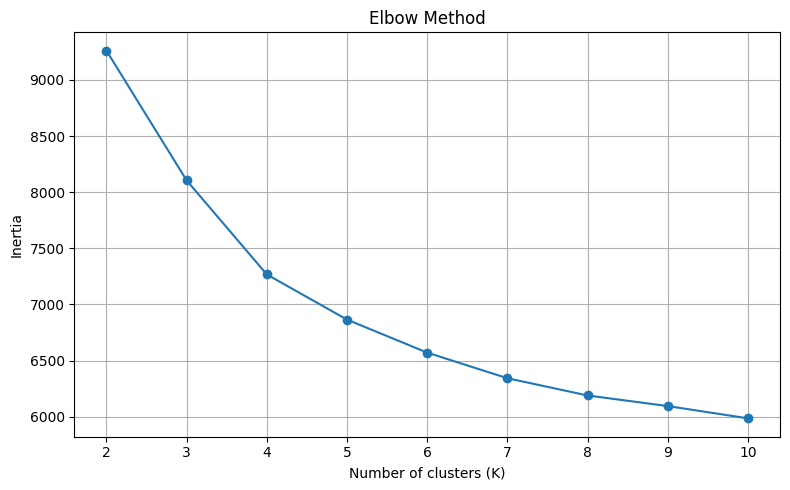

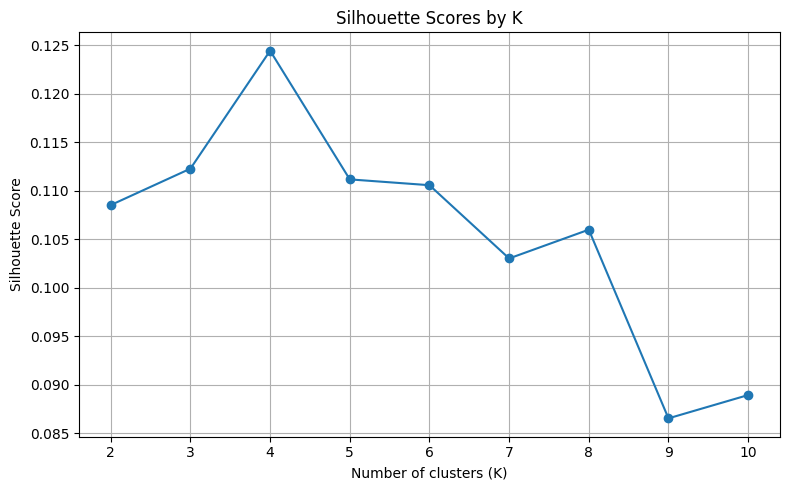


Running final K-means with K=4...

Done.

Saved: encoded_with_employee.csv
Saved: encoded_features_only.csv
Saved: employees_with_clusters.csv
Saved: cluster_summary.csv


In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# =========================================================
# CONFIGURATION
# =========================================================
INPUT_CSV = "5_2023_urbanCategoryFound.csv"

EMPLOYEE_COL = "employee"

ONE_CHOICE_COLUMNS = [
    "age_group",
    "home_location_type",
    "office_location_type",
    "family_unit",
    "distance_of_pt_stop_closest_to_the_home",
    "gender",
    "working_time_arrangement",
    "accompanying_people",
    "during_journey_stops"
]

MULTI_CHOICE_COLUMNS = [
    "available_means_transport"
]

NUMERIC_COLUMNS = [
    "days_per_month_of_work_on_site",
    "QEMTRPDIST"
]

MULTI_SEPARATOR = "^"

K_RANGE = range(2, 11)
FINAL_K = 4   # change after inspecting elbow and silhouette

# Output files
ENCODED_WITH_EMPLOYEE_CSV = "encoded_with_employee.csv"
FEATURES_ONLY_CSV = "encoded_features_only.csv"
CLUSTERED_OUTPUT_CSV = "employees_with_clusters.csv"
CLUSTER_SUMMARY_CSV = "cluster_summary.csv"

# =========================================================
# LOAD DATA
# =========================================================
df = pd.read_csv(INPUT_CSV, encoding="ISO-8859-1")

if EMPLOYEE_COL not in df.columns:
    raise ValueError(f"Missing required column: {EMPLOYEE_COL}")

# Keep only existing columns
one_choice_cols = [c for c in ONE_CHOICE_COLUMNS if c in df.columns]
multi_choice_cols = [c for c in MULTI_CHOICE_COLUMNS if c in df.columns]
numeric_cols = [c for c in NUMERIC_COLUMNS if c in df.columns]

# =========================================================
# START ENCODED DATAFRAME WITH EMPLOYEE
# =========================================================
encoded_df = df[[EMPLOYEE_COL]].copy()

# =========================================================
# 1) ONE-HOT ENCODING FOR ONE-CHOICE COLUMNS
# =========================================================
if one_choice_cols:
    one_choice_df = df[one_choice_cols].copy()

    for col in one_choice_cols:
        one_choice_df[col] = (
            one_choice_df[col]
            .fillna("MISSING")
            .astype(str)
            .str.strip()
        )

    one_hot_df = pd.get_dummies(
        one_choice_df,
        columns=one_choice_cols,
        prefix=one_choice_cols,
        prefix_sep="__",
        dtype=int
    )

    encoded_df = pd.concat([encoded_df, one_hot_df], axis=1)

# =========================================================
# 2) MULTI-HOT ENCODING FOR MULTIPLE-CHOICE COLUMNS
# =========================================================
for col in multi_choice_cols:
    series = df[col].fillna("").astype(str).str.strip()

    all_options = set()

    for value in series:
        if not value:
            continue
        parts = [p.strip() for p in value.split(MULTI_SEPARATOR) if p.strip()]
        all_options.update(parts)

    all_options = sorted(all_options)

    for option in all_options:
        new_col = f"{col}__{option}"
        encoded_df[new_col] = series.apply(
            lambda x: int(option in [p.strip() for p in x.split(MULTI_SEPARATOR) if p.strip()])
        )

# =========================================================
# 3) KEEP NUMERIC COLUMNS AND SCALE THEM
# =========================================================
if numeric_cols:
    numeric_df = df[numeric_cols].copy()

    for col in numeric_cols:
        numeric_df[col] = pd.to_numeric(numeric_df[col], errors="coerce")
        numeric_df[col] = numeric_df[col].fillna(numeric_df[col].median())

    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(numeric_df)

    scaled_numeric_df = pd.DataFrame(
        scaled_array,
        columns=[f"{col}__scaled" for col in numeric_cols],
        index=df.index
    )

    encoded_df = pd.concat([encoded_df, scaled_numeric_df], axis=1)

# =========================================================
# SAVE ENCODED DATA
# =========================================================
encoded_df.to_csv(ENCODED_WITH_EMPLOYEE_CSV, index=False)

features_df = encoded_df.drop(columns=[EMPLOYEE_COL]).copy()
features_df.to_csv(FEATURES_ONLY_CSV, index=False)

# =========================================================
# 4) PREPARE FEATURE MATRIX FOR K-MEANS
# =========================================================
X = features_df.values

# =========================================================
# 5) TEST DIFFERENT K VALUES
# =========================================================
inertia_values = []
silhouette_values = []

print("Evaluating K values...\n")

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_
    sil_score = silhouette_score(X, labels)

    inertia_values.append(inertia)
    silhouette_values.append(sil_score)

    print(f"K={k} | Inertia={inertia:.2f} | Silhouette={sil_score:.4f}")

# =========================================================
# 6) PLOT ELBOW METHOD
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(list(K_RANGE), inertia_values, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 7) PLOT SILHOUETTE SCORES
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(list(K_RANGE), silhouette_values, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by K")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 8) FINAL K-MEANS WITH CHOSEN K
# =========================================================
print(f"\nRunning final K-means with K={FINAL_K}...\n")

final_kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X)

# Add cluster labels back
clustered_df = encoded_df.copy()
clustered_df["cluster"] = final_labels
clustered_df.to_csv(CLUSTERED_OUTPUT_CSV, index=False)

# =========================================================
# 9) CLUSTER SUMMARY / PROFILE
# =========================================================
cluster_summary = clustered_df.drop(columns=[EMPLOYEE_COL]).groupby("cluster").mean()
cluster_summary.to_csv(CLUSTER_SUMMARY_CSV)

print("Done.\n")
print(f"Saved: {ENCODED_WITH_EMPLOYEE_CSV}")
print(f"Saved: {FEATURES_ONLY_CSV}")
print(f"Saved: {CLUSTERED_OUTPUT_CSV}")
print(f"Saved: {CLUSTER_SUMMARY_CSV}")

In [7]:
df = pd.read_csv("employees_with_clusters.csv")

In [8]:
cluster_summary = df.groupby("cluster").mean()
cluster_summary.to_csv("cluster_summary.csv")

print(cluster_summary.T)

cluster                                                        0  \
employee                                            1.039680e+09   
age_group__36_40                                    1.839080e-01   
age_group__41_55                                    6.781609e-01   
age_group__56_60                                    6.896552e-02   
age_group__less_than_35                             5.172414e-02   
age_group__more_than_60                             1.724138e-02   
family_unit__1                                      1.896552e-01   
family_unit__2                                      1.839080e-01   
family_unit__3                                      2.471264e-01   
family_unit__4                                      3.275862e-01   
family_unit__more_than_4                            5.172414e-02   
gender__female                                      3.735632e-01   
gender__male                                        6.206897e-01   
gender__preferisco non dichiarare               

In [9]:
important_cols = [col for col in df.columns if "choice_reason__" in col]

print(cluster_summary[important_cols].T)

cluster                                           0         1         2  \
choice_reason__accompany_people            0.109195  0.125320  0.006051   
choice_reason__autonomoy_of_movement       0.287356  0.335038  0.344932   
choice_reason__comfort                     0.132184  0.102302  0.140696   
choice_reason__economy                     0.235632  0.276215  0.276853   
choice_reason__extra_work_activity         0.034483  0.015345  0.027231   
choice_reason__health                      0.051724  0.046036  0.052950   
choice_reason__inefficient_public_service  0.195402  0.196931  0.173979   
choice_reason__lack_of_cycle_path          0.045977  0.025575  0.045386   
choice_reason__lack_of_valid_alternative   0.310345  0.281330  0.229955   
choice_reason__less_stressful_alternative  0.247126  0.342711  0.375189   
choice_reason__parking_difficulties        0.126437  0.102302  0.101362   
choice_reason__respect_for_environment     0.051724  0.071611  0.092284   
choice_reason__safety    

In [11]:
global_mean = df.drop(columns=["employee", "cluster"]).mean()

deviation = cluster_summary - global_mean

In [13]:
top_features = {}

for c in deviation.index:
    # Top positive deviations
    top_positive = deviation.loc[c].sort_values(ascending=False).head(5)

    # Top negative deviations
    top_negative = deviation.loc[c].sort_values(ascending=True).head(5)

    top_features[c] = {
        "positive": top_positive,
        "negative": top_negative
    }

# Print nicely
for c, feats in top_features.items():
    print(f"\n===== Cluster {c} =====")

    print("\nTop OVER-represented features:")
    print(feats["positive"])

    print("\nTop UNDER-represented features:")
    print(feats["negative"])


===== Cluster 0 =====

Top OVER-represented features:
days_per_month_of_work_on_site__scaled      2.196490
age_group__36_40                            0.089544
accompanying_people__no                     0.066344
choice_reason__lack_of_valid_alternative    0.050188
family_unit__1                              0.029105
Name: 0, dtype: float64

Top UNDER-represented features:
choice_reason__travel_time                  -0.107998
choice_reason__less_stressful_alternative   -0.091012
age_group__41_55                            -0.067580
accompanying_people__yes                    -0.066344
choice_reason__autonomoy_of_movement        -0.063889
Name: 0, dtype: float64

===== Cluster 1 =====

Top OVER-represented features:
accompanying_people__yes    0.502621
gender__male                0.372279
family_unit__4              0.149342
family_unit__3              0.090226
age_group__41_55            0.065001
Name: 1, dtype: float64

Top UNDER-represented features:
accompanying_people__no         